# PEMS08 Traffic Flow — v4 (Architecture Change)

## Why previous versions kept failing
The gap (val - train ≈ 0.03) never closed despite tuning dropout/LR/weight-decay.
This means the problem is **structural overfitting** — the LSTM+Transformer was
too powerful and memorised training patterns that don't generalise.

## New approach: TCN (Temporal Convolutional Network)
- Dilated causal convolutions capture long-range temporal patterns efficiently
- Far fewer parameters → much harder to overfit
- Proven to outperform LSTM on many time-series benchmarks
- Trains faster on GPU due to parallelism (no sequential LSTM bottleneck)

In [1]:
from google.colab import files
uploaded  = files.upload()
DATA_PATH = list(uploaded.keys())[0]

# ── Option B: Mount Google Drive ────────────────────────────────────────────
# from google.colab import drive
# drive.mount('/content/drive')
# DATA_PATH = '/content/drive/MyDrive/PEMS08.npz'

Saving PEMS08.npz to PEMS08.npz


In [2]:
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
if device.type == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [3]:
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

In [4]:
data = np.load(DATA_PATH)
arr  = data['data']
flow = arr[:, :, 0]          # (time, 170 sensors)
print('Dataset shape:', flow.shape)

Dataset shape: (17856, 170)


In [5]:
split_index = int(0.8 * len(flow))
mean = flow[:split_index].mean()
std  = flow[:split_index].std()
flow = (flow - mean) / std
print(f'mean={mean:.2f}  std={std:.2f}')

mean=230.56  std=146.18


In [6]:
SEQ_LEN  = 48
PRED_LEN = 1

X, Y = [], []
for i in range(len(flow) - SEQ_LEN - PRED_LEN):
    X.append(flow[i : i + SEQ_LEN])                          # (48, 170)
    Y.append(flow[i + SEQ_LEN : i + SEQ_LEN + PRED_LEN])    # (1,  170)

X = np.array(X, dtype=np.float32)   # (N, 48, 170)
Y = np.array(Y, dtype=np.float32)   # (N,  1, 170)

split     = int(0.8 * len(X))
val_split = int(0.9 * split)

X_train, Y_train = X[:val_split],      Y[:val_split]
X_val,   Y_val   = X[val_split:split], Y[val_split:split]
X_test,  Y_test  = X[split:],          Y[split:]

print(f'Train {X_train.shape} | Val {X_val.shape} | Test {X_test.shape}')

Train (12820, 48, 170) | Val (1425, 48, 170) | Test (3562, 48, 170)


In [7]:
class TrafficDataset(Dataset):
    def __init__(self, X, Y):
        # TCN expects (batch, channels, time) → transpose here
        self.X = torch.from_numpy(X).permute(0, 2, 1)  # (N, 170, 48)
        self.Y = torch.from_numpy(Y)                    # (N,   1, 170)
    def __len__(self):          return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.Y[idx]

BATCH = 128
train_loader = DataLoader(TrafficDataset(X_train, Y_train), batch_size=BATCH, shuffle=True,  pin_memory=True, num_workers=2)
val_loader   = DataLoader(TrafficDataset(X_val,   Y_val),   batch_size=BATCH, shuffle=False, pin_memory=True, num_workers=2)
test_loader  = DataLoader(TrafficDataset(X_test,  Y_test),  batch_size=BATCH, shuffle=False, pin_memory=True, num_workers=2)

In [8]:
# ── TCN building block ───────────────────────────────────────────────────────
class TemporalBlock(nn.Module):
    """Dilated causal convolution with residual connection."""
    def __init__(self, in_ch, out_ch, kernel_size, dilation, dropout=0.2):
        super().__init__()
        pad = (kernel_size - 1) * dilation   # causal padding

        self.conv1 = nn.Conv1d(in_ch,  out_ch, kernel_size, padding=pad, dilation=dilation)
        self.conv2 = nn.Conv1d(out_ch, out_ch, kernel_size, padding=pad, dilation=dilation)
        self.norm1 = nn.BatchNorm1d(out_ch)
        self.norm2 = nn.BatchNorm1d(out_ch)
        self.drop  = nn.Dropout(dropout)
        self.skip  = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x):
        # Causal: trim the future-padding from the right
        h = self.drop(F.relu(self.norm1(self.conv1(x)[:, :, :x.size(2)])))
        h = self.drop(F.relu(self.norm2(self.conv2(h)[:, :, :x.size(2)])))
        return F.relu(h + self.skip(x))


# ── Full TCN model ───────────────────────────────────────────────────────────
class TCN(nn.Module):
    """
    Input:  (batch, 170, 48)  — 170 sensors, 48 time steps
    Output: (batch, 1,  170)  — 1 step ahead for all sensors
    """
    def __init__(self, sensors=170, channels=64, kernel_size=3, dropout=0.2):
        super().__init__()
        # Stacked dilated blocks: receptive field = 1 + 2*(k-1)*(1+2+4+8) = 97 steps
        self.tcn = nn.Sequential(
            TemporalBlock(sensors,   channels,     kernel_size, dilation=1,  dropout=dropout),
            TemporalBlock(channels,  channels,     kernel_size, dilation=2,  dropout=dropout),
            TemporalBlock(channels,  channels * 2, kernel_size, dilation=4,  dropout=dropout),
            TemporalBlock(channels*2,channels * 2, kernel_size, dilation=8,  dropout=dropout),
        )
        self.fc = nn.Linear(channels * 2, sensors)

    def forward(self, x):              # x: (B, 170, 48)
        h = self.tcn(x)               # (B, channels*2, 48)
        h = self.fc(h[:, :, -1])      # last time step → (B, 170)
        return h.unsqueeze(1)         # (B, 1, 170)


model = TCN(sensors=170, channels=64, kernel_size=3, dropout=0.2).to(device)
total = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'TCN parameters: {total:,}  (much fewer than LSTM+Transformer)')

TCN parameters: 285,034  (much fewer than LSTM+Transformer)


In [9]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-6
)

EPOCHS           = 100
patience         = 15
best_val_loss    = float('inf')
patience_counter = 0
train_losses, val_losses = [], []

for epoch in range(EPOCHS):

    # Training
    model.train()
    train_loss = 0.0
    for x, y in train_loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            val_loss += criterion(model(x), y).item()
    val_loss /= len(val_loader)
    val_losses.append(val_loss)

    scheduler.step(val_loss)
    lr  = optimizer.param_groups[0]['lr']
    gap = val_loss - train_loss
    print(f'Epoch {epoch+1:3d} | Train {train_loss:.4f} | Val {val_loss:.4f} | Gap {gap:.4f} | LR {lr:.2e}')

    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'best_model.pth')
    else:
        patience_counter += 1
    if patience_counter >= patience:
        print('Early stopping triggered')
        break

model.load_state_dict(torch.load('best_model.pth'))
print('Best model loaded!')

Epoch   1 | Train 0.1929 | Val 0.1245 | Gap -0.0684 | LR 1.00e-03
Epoch   2 | Train 0.0643 | Val 0.1125 | Gap 0.0482 | LR 1.00e-03
Epoch   3 | Train 0.0526 | Val 0.1044 | Gap 0.0518 | LR 1.00e-03
Epoch   4 | Train 0.0457 | Val 0.1005 | Gap 0.0548 | LR 1.00e-03
Epoch   5 | Train 0.0414 | Val 0.0956 | Gap 0.0542 | LR 1.00e-03
Epoch   6 | Train 0.0383 | Val 0.0911 | Gap 0.0528 | LR 1.00e-03
Epoch   7 | Train 0.0360 | Val 0.0854 | Gap 0.0493 | LR 1.00e-03
Epoch   8 | Train 0.0345 | Val 0.0815 | Gap 0.0470 | LR 1.00e-03
Epoch   9 | Train 0.0332 | Val 0.0801 | Gap 0.0469 | LR 1.00e-03
Epoch  10 | Train 0.0322 | Val 0.0758 | Gap 0.0435 | LR 1.00e-03
Epoch  11 | Train 0.0313 | Val 0.0720 | Gap 0.0407 | LR 1.00e-03
Epoch  12 | Train 0.0306 | Val 0.0710 | Gap 0.0404 | LR 1.00e-03
Epoch  13 | Train 0.0299 | Val 0.0695 | Gap 0.0396 | LR 1.00e-03
Epoch  14 | Train 0.0294 | Val 0.0672 | Gap 0.0378 | LR 1.00e-03
Epoch  15 | Train 0.0288 | Val 0.0651 | Gap 0.0362 | LR 1.00e-03
Epoch  16 | Train 0.0285

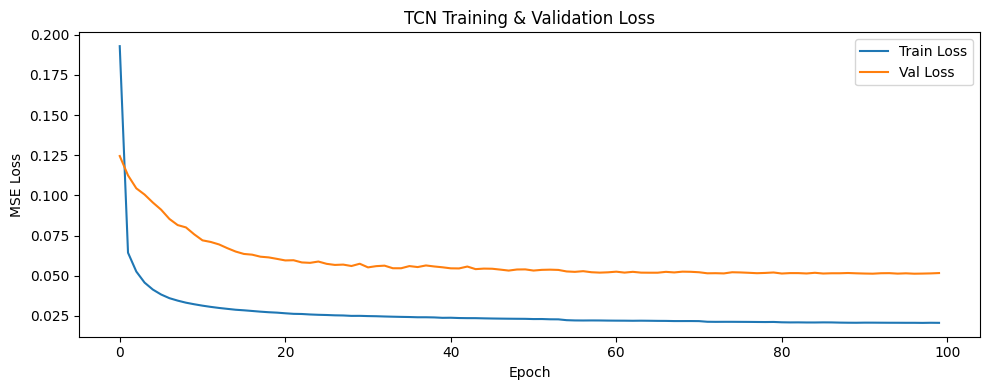

Final gap: 0.0310  ← target < 0.01


In [10]:
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses,   label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('TCN Training & Validation Loss')
plt.legend()
plt.tight_layout()
plt.show()
print(f'Final gap: {val_losses[-1] - train_losses[-1]:.4f}  ← target < 0.01')

MAE:  16.5901
RMSE: 25.2296
MAPE: 11.4552%  (flow > 1 only)


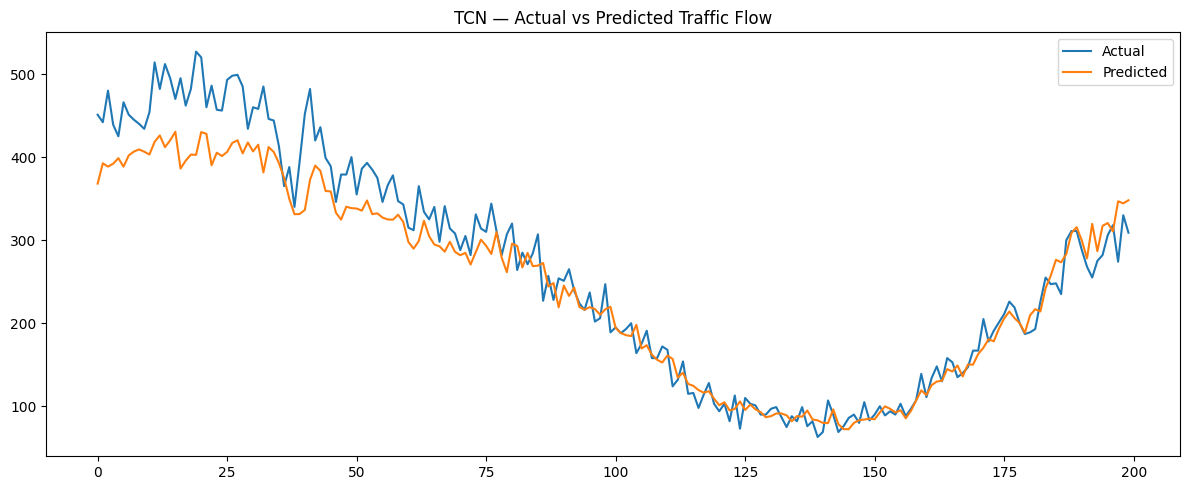

In [11]:
model.eval()
preds, actual = [], []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device, non_blocking=True)
        preds.append(model(x).cpu().numpy())
        actual.append(y.numpy())

preds  = np.concatenate(preds)   # (N, 1, 170)
actual = np.concatenate(actual)

# Denormalise
preds  = preds  * std + mean
actual = actual * std + mean

mae  = mean_absolute_error(actual.flatten(), preds.flatten())
rmse = np.sqrt(mean_squared_error(actual.flatten(), preds.flatten()))
mask = actual.flatten() > 1.0
mape = np.mean(np.abs((actual.flatten()[mask] - preds.flatten()[mask]) /
                       actual.flatten()[mask])) * 100

print(f'MAE:  {mae:.4f}')
print(f'RMSE: {rmse:.4f}')
print(f'MAPE: {mape:.4f}%  (flow > 1 only)')

plt.figure(figsize=(12, 5))
plt.plot(actual[:200, 0, 0], label='Actual')
plt.plot(preds[:200,  0, 0], label='Predicted')
plt.legend()
plt.title('TCN — Actual vs Predicted Traffic Flow')
plt.tight_layout()
plt.show()